# 批量归一化

现在主流的卷积神经网络几乎都使用了批量归一化

批量归一化是一种流行且有效的技术，它可以持续加速深层网络的收敛速度

## 基础知识

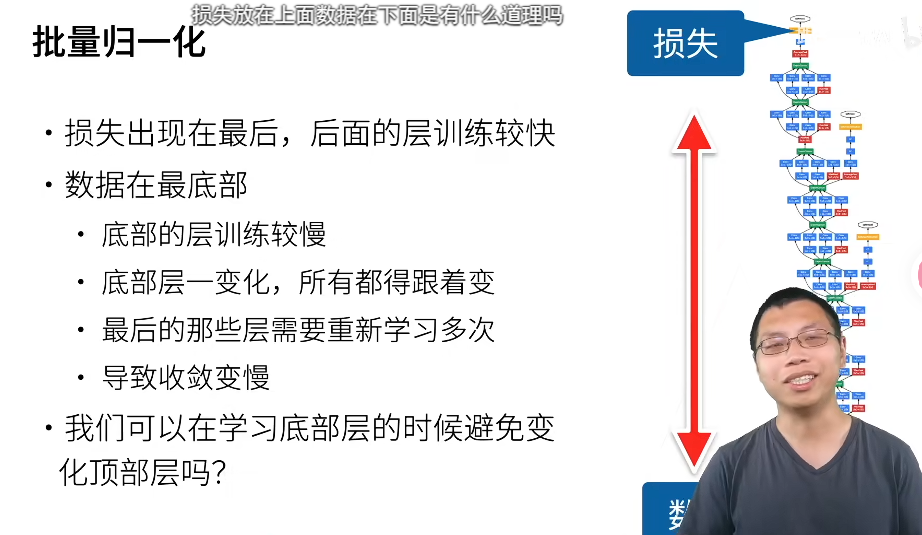

数据在最底层，损失在最高层，底部层负责学习数据的低级特征（非常重要）

正向传递的时候，数据是从下往上一步一步往上传递

反向传递的时候，数据是从上面往下传递，如果出现**梯度消失**问题：梯度在上面的时候比较大，越到下面就越容易变小（因为是n个很小的数进行相乘，越到后面结果就越小，也就是说**越靠近数据的层的梯度就越小**）

协变量偏移（Covariate Shift）：网络每层依赖前一层学习结果，**底层一变化（参数更新），其他层要重新学习适应变化**

底层梯度小，参数学习收敛慢，上层收敛快，但上层要随底层变化而重新计算，由于底层特征的不稳定性和上层对底层变化的敏感性，整个网络的训练过程可能会变得缓慢和困难。

**能不能在改变底部信息的时候，避免顶部不断的重新训练？**

Batch Normalization：将不同层的不同位置的小批量（mini-batch）输出的均值和方差固定

顶层接收到的输入分布被“锚定”在了一个稳定的标准正态分布附近。底层参数再怎么变，传递到顶层的“数据形态”（分布）几乎是恒定的。顶层不再需要感知底层的数值漂移，只需要在当前这个固定分布下做特征提取即可。

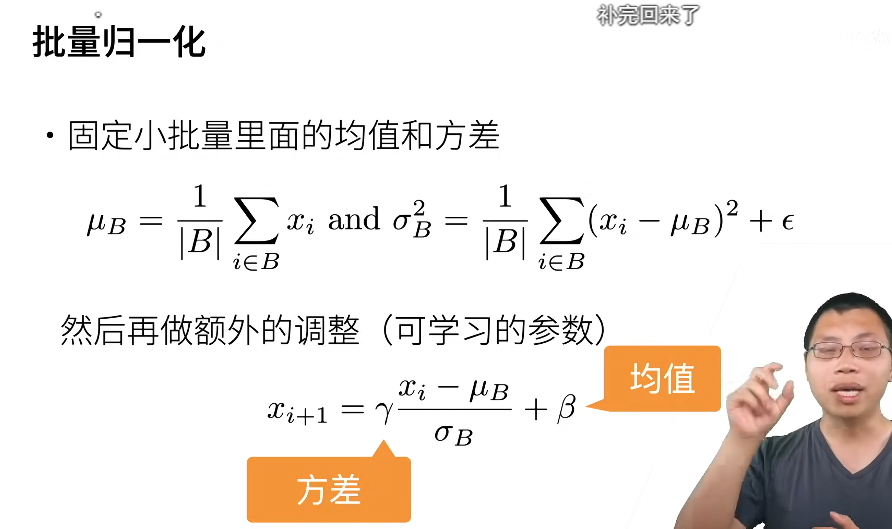

减均值，除以标准差就是正则化，由原始分布近似限定为均值为0方差为1的正态分布，再做额外调整（2个可学习参数）

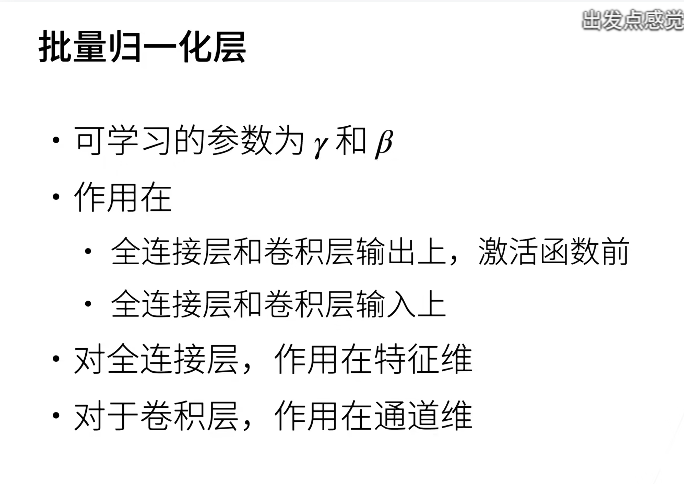

BN 一般放在全连接/卷积层之后，激活函数前。

BN 作用在全连接层的**特征维**

BN作用在卷积层**输出通道维**：输出通道维就是**特征**维度，像素点作为样本，通道作为特征

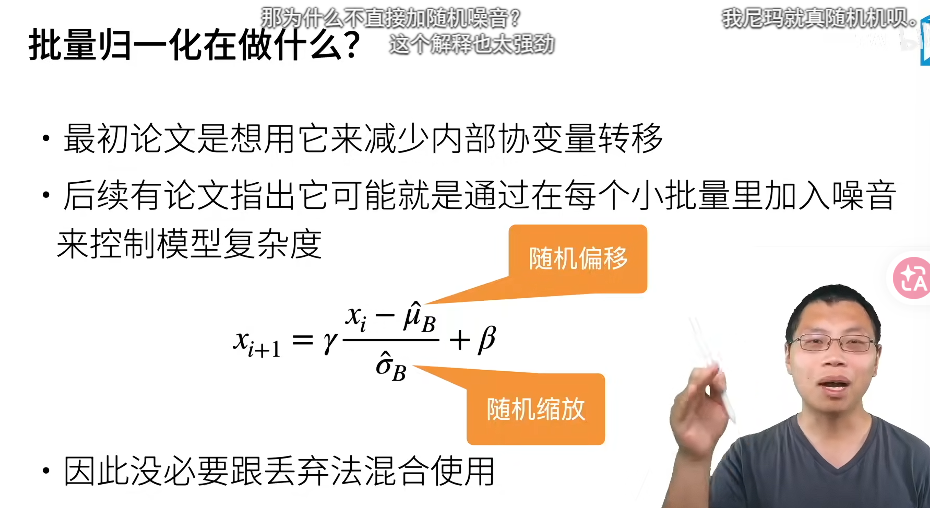

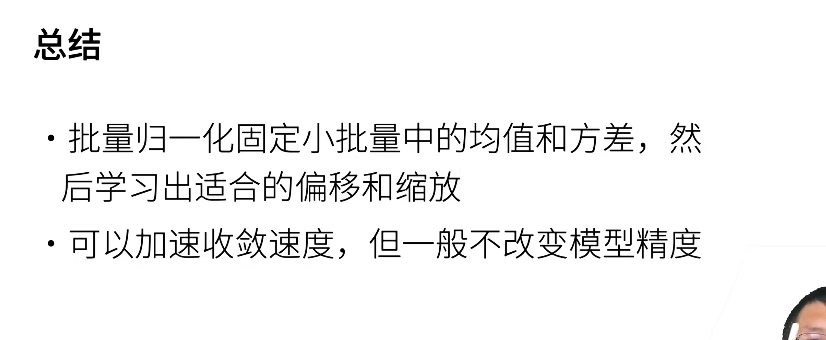

## 代码

In [1]:
import torch
from torch import nn
from d2l import torch as d2l
# moving_mean, moving_var全局均值和方差
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # 通过is_grad_enabled来判断当前模式是训练模式还是预测模式
    if not torch.is_grad_enabled():
        # 如果是在预测模式下，直接使用传入的移动平均所得的均值和方差
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        # 断言检查x, 2维 (批量大小, 特征数) → 对应全连接层。
        # 4维 (批量大小, 通道数, 高, 宽) → 对应卷积层。
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # 使用全连接层的情况，计算特征维上的均值和方差
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # 使用二维卷积层的情况，计算通道维上（axis=1）的均值和方差。
            # 这里我们需要保持X的形状以便后面可以做广播运算
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # 训练模式下，用当前的均值和方差做标准化
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # 更新移动平均的均值和方差
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta  # 缩放和移位
    return Y, moving_mean.data, moving_var.data

In [2]:
class BatchNorm(nn.Module):
    # num_features：完全连接层的输出数量或卷积层的输出通道数。
    # num_dims：2表示完全连接层，4表示卷积层
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # 参与求梯度和迭代的拉伸和偏移参数，分别初始化成1和0
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # 非模型参数的变量初始化为0和1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # 如果X不在内存上，将moving_mean和moving_var复制到X所在显存上
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # 保存更新过的moving_mean和moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.9)
        return Y

放在全连接层和卷积层后，激活函数之前

In [3]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), BatchNorm(6, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16*4*4, 120), BatchNorm(120, num_dims=2), nn.Sigmoid(),
    nn.Linear(120, 84), BatchNorm(84, num_dims=2), nn.Sigmoid(),
    nn.Linear(84, 10))

loss 0.271, train acc 0.899, test acc 0.868
3092.9 examples/sec on cpu


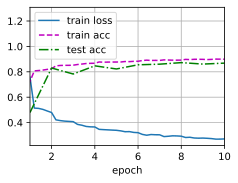

In [4]:
lr, num_epochs, batch_size = 1.0, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

从第⼀个批量规范化层中学到的拉伸参数gamma和偏移参数beta

In [5]:
net[1].gamma.reshape((-1,)), net[1].beta.reshape((-1,))

(tensor([4.8830, 2.1059, 2.2809, 3.2498, 1.6909, 0.2101],
        grad_fn=<ViewBackward0>),
 tensor([ 2.5695,  0.9637, -2.9304, -3.1411, -2.2748, -0.5051],
        grad_fn=<ViewBackward0>))

简洁实现

In [6]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10))

loss 0.269, train acc 0.900, test acc 0.884
3940.2 examples/sec on cpu


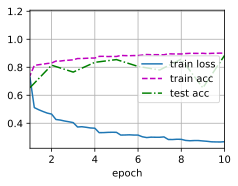

In [7]:
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

加入BN后收敛时间变短，有一种解释，认为BN之后地形图更加平坦，容易收敛